# Chapter 18: Entropy Features

**AFML Ch. 18** -- Information-theoretic features for market microstructure.

Entropy measures quantify the amount of information (or randomness) in a time series.
Low-entropy regimes are more predictable, while high-entropy regimes are closer to random.
This notebook demonstrates encoding schemes and entropy estimators implemented in `pymlfinance`.

**Topics covered:**

- Binary, quantile, and sigma encoding
- Shannon entropy
- Plugin entropy estimator
- Kontoyiannis entropy estimator
- Lempel-Ziv complexity
- Polars integration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pymlfinance
import pymlfinance.polars

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
np.random.seed(42)

## Generate Synthetic Series

We construct a series with four distinct regimes to study how entropy varies
with the underlying generating process:

| Regime | Bars | Description |
|:---:|:---:|:---|
| 1 | 0--100 | Trending (positive drift) |
| 2 | 100--250 | Random walk |
| 3 | 250--350 | Mean-reverting |
| 4 | 350--500 | Random walk |

In [2]:
n = 500
# Mixture: trending periods + random periods
trend_period = np.cumsum(np.ones(100) * 0.01 + np.random.randn(100) * 0.002)
random_period = np.cumsum(np.random.randn(150) * 0.01)
mean_rev = np.cumsum(-0.1 * np.random.randn(100).cumsum() * 0.01 + np.random.randn(100) * 0.005)
random_period2 = np.cumsum(np.random.randn(150) * 0.01)
series = np.concatenate([trend_period, random_period, mean_rev, random_period2])

print(f"Generated {len(series)} observations")
print(f"  Regime 1 (0-100): trending")
print(f"  Regime 2 (100-250): random")
print(f"  Regime 3 (250-350): mean-reverting")
print(f"  Regime 4 (350-500): random")

Generated 500 observations
  Regime 1 (0-100): trending
  Regime 2 (100-250): random
  Regime 3 (250-350): mean-reverting
  Regime 4 (350-500): random


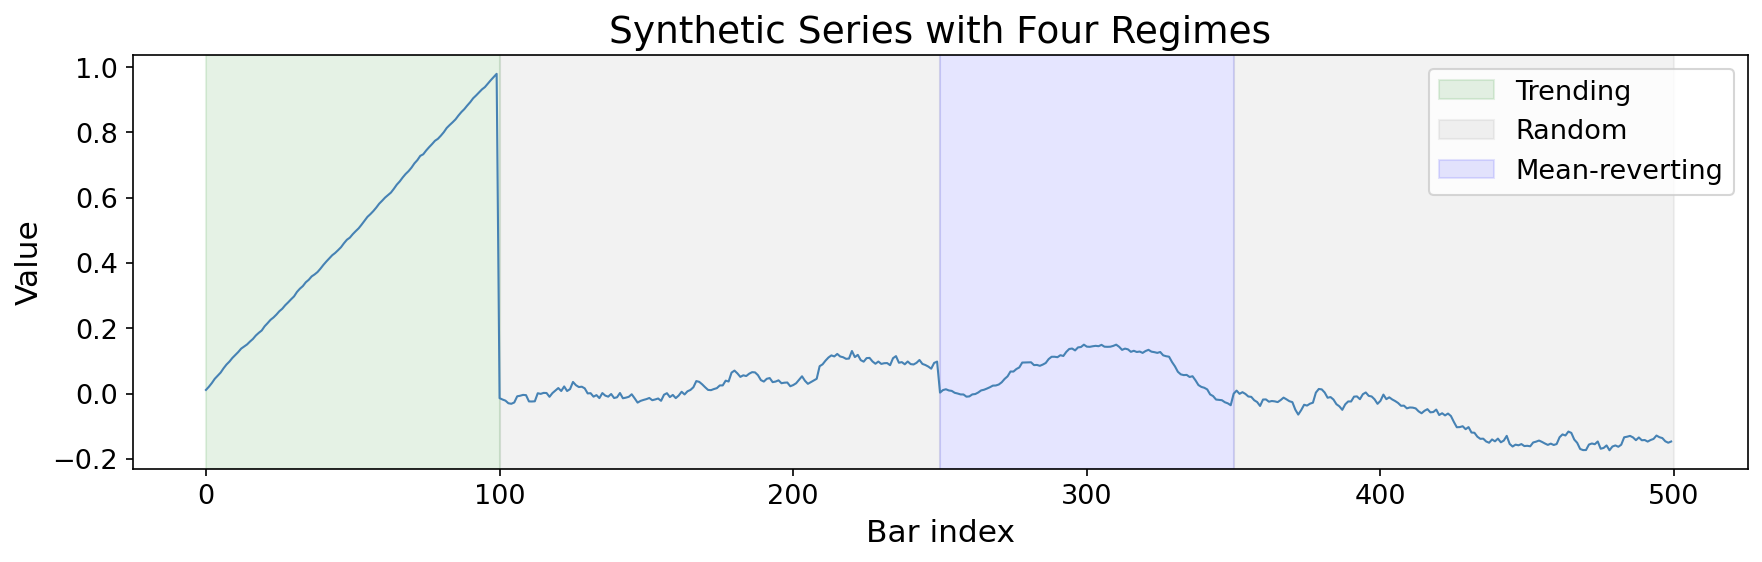

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series, color="steelblue", linewidth=1)
ax.axvspan(0, 100, alpha=0.1, color="green", label="Trending")
ax.axvspan(100, 250, alpha=0.1, color="gray", label="Random")
ax.axvspan(250, 350, alpha=0.1, color="blue", label="Mean-reverting")
ax.axvspan(350, 500, alpha=0.1, color="gray")
ax.set_xlabel("Bar index")
ax.set_ylabel("Value")
ax.set_title("Synthetic Series with Four Regimes")
ax.legend()
plt.tight_layout()
plt.show()

## Encoding Methods

Before computing entropy, continuous series must be discretized (encoded) into a finite
alphabet. Three encoding schemes are available:

- **Binary encoding**: Above/below median (2 symbols)
- **Quantile encoding**: Equal-frequency bins (k symbols)
- **Sigma encoding**: Standard-deviation bands around the mean (2k+1 symbols)

In [4]:
print(f"--- Binary Encoding ---")
binary = pymlfinance.features.binary_encode(series)
print(f"  Length: {len(binary)}")
print(f"  True (above median): {sum(binary)}, False (below): {len(binary) - sum(binary)}")

--- Binary Encoding ---
  Length: 500
  True (above median): 300, False (below): 200


In [5]:
print(f"--- Quantile Encoding ---")
for n_bins in [4, 8, 16]:
    quantile = pymlfinance.features.quantile_encode(series, num_bins=n_bins)
    unique = len(set(quantile))
    print(f"  {n_bins} bins: {unique} unique values, "
          f"distribution: {[quantile.count(i) for i in range(min(n_bins, 4))]}")

--- Quantile Encoding ---
  4 bins: 4 unique values, distribution: [125, 125, 125, 125]
  8 bins: 8 unique values, distribution: [62, 63, 62, 63]
  16 bins: 16 unique values, distribution: [31, 31, 31, 32]


In [6]:
print(f"--- Sigma Encoding ---")
for n_bands in [2, 3, 5]:
    sigma = pymlfinance.features.sigma_encode(series, num_bands=n_bands)
    unique = len(set(sigma))
    print(f"  {n_bands} bands: {unique} unique values")

--- Sigma Encoding ---
  2 bands: 2 unique values
  3 bands: 3 unique values
  5 bands: 5 unique values


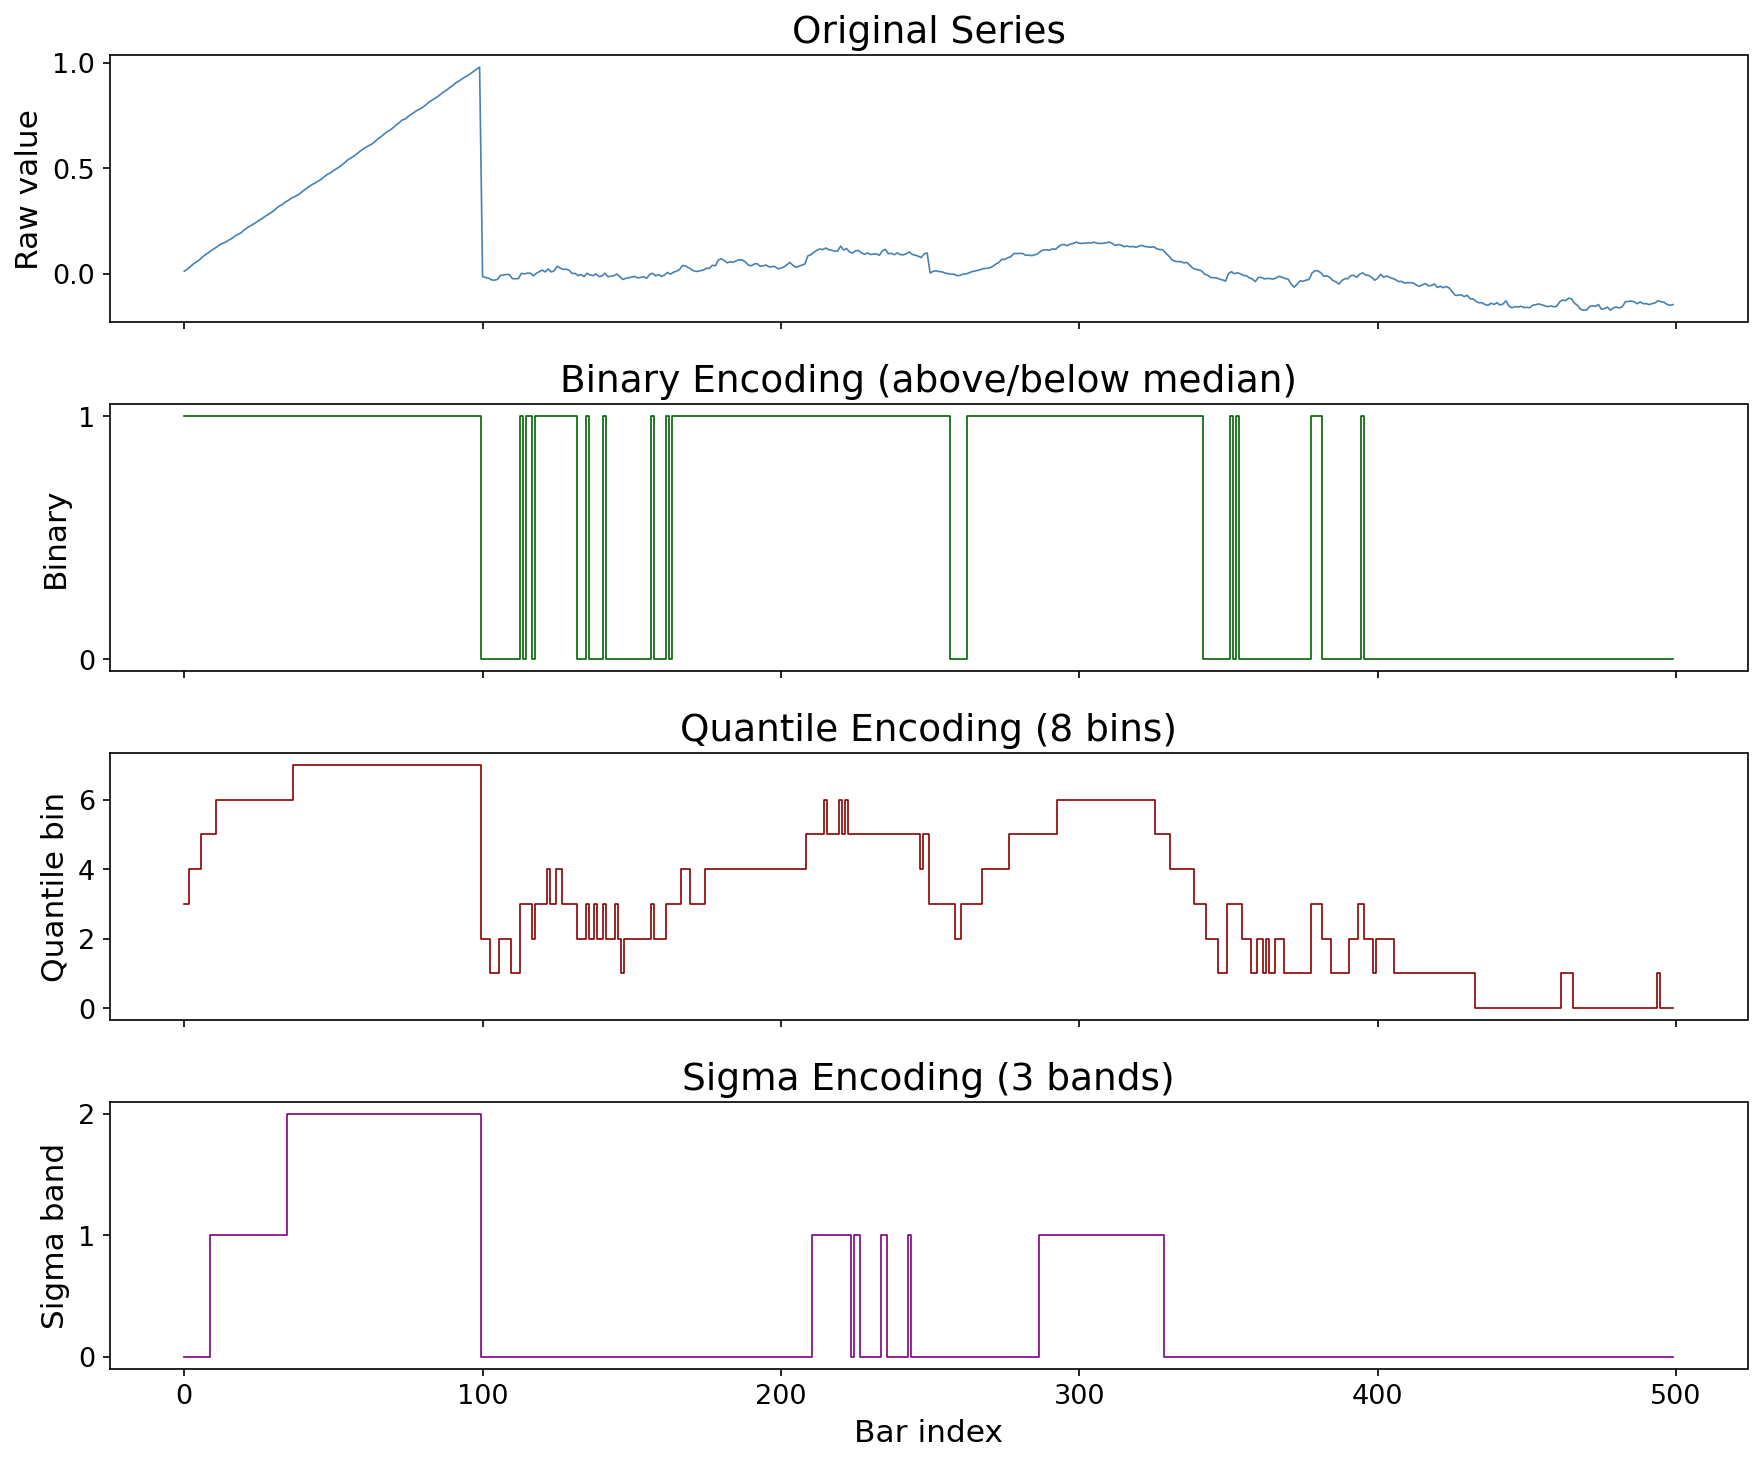

In [7]:
# Visualize the three encoding methods side by side
binary_vals = [int(b) for b in binary]
quantile_8 = pymlfinance.features.quantile_encode(series, num_bins=8)
sigma_3 = pymlfinance.features.sigma_encode(series, num_bands=3)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(series, color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Raw value")
axes[0].set_title("Original Series")

axes[1].step(range(len(binary_vals)), binary_vals, color="darkgreen", linewidth=0.8, where="mid")
axes[1].set_ylabel("Binary")
axes[1].set_title("Binary Encoding (above/below median)")
axes[1].set_yticks([0, 1])

axes[2].step(range(len(quantile_8)), quantile_8, color="darkred", linewidth=0.8, where="mid")
axes[2].set_ylabel("Quantile bin")
axes[2].set_title("Quantile Encoding (8 bins)")

axes[3].step(range(len(sigma_3)), sigma_3, color="purple", linewidth=0.8, where="mid")
axes[3].set_ylabel("Sigma band")
axes[3].set_xlabel("Bar index")
axes[3].set_title("Sigma Encoding (3 bands)")

plt.tight_layout()
plt.show()

## Shannon Entropy

Shannon entropy measures the expected information content of a probability distribution.
Maximum entropy corresponds to a uniform distribution (maximum uncertainty), while
minimum entropy occurs when the distribution is concentrated on a single outcome.

$$H(X) = -\sum_{i} p_i \log(p_i)$$

In [8]:
# Uniform distribution
uniform_probs = np.ones(10) / 10
h_uniform = pymlfinance.features.shannon_entropy(uniform_probs)
# Peaked distribution
peaked_probs = np.array([0.9, 0.05, 0.02, 0.01, 0.01, 0.005, 0.003, 0.001, 0.0005, 0.0005])
peaked_probs /= peaked_probs.sum()
h_peaked = pymlfinance.features.shannon_entropy(peaked_probs)
# Binary
binary_probs = np.array([0.5, 0.5])
h_binary = pymlfinance.features.shannon_entropy(binary_probs)
print(f"  Uniform (10 symbols): {h_uniform:.4f} nats (max entropy)")
print(f"  Peaked (10 symbols):  {h_peaked:.4f} nats (low entropy)")
print(f"  Binary (50/50):       {h_binary:.4f} nats")

  Uniform (10 symbols): 3.3219 nats (max entropy)
  Peaked (10 symbols):  0.6829 nats (low entropy)
  Binary (50/50):       1.0000 nats


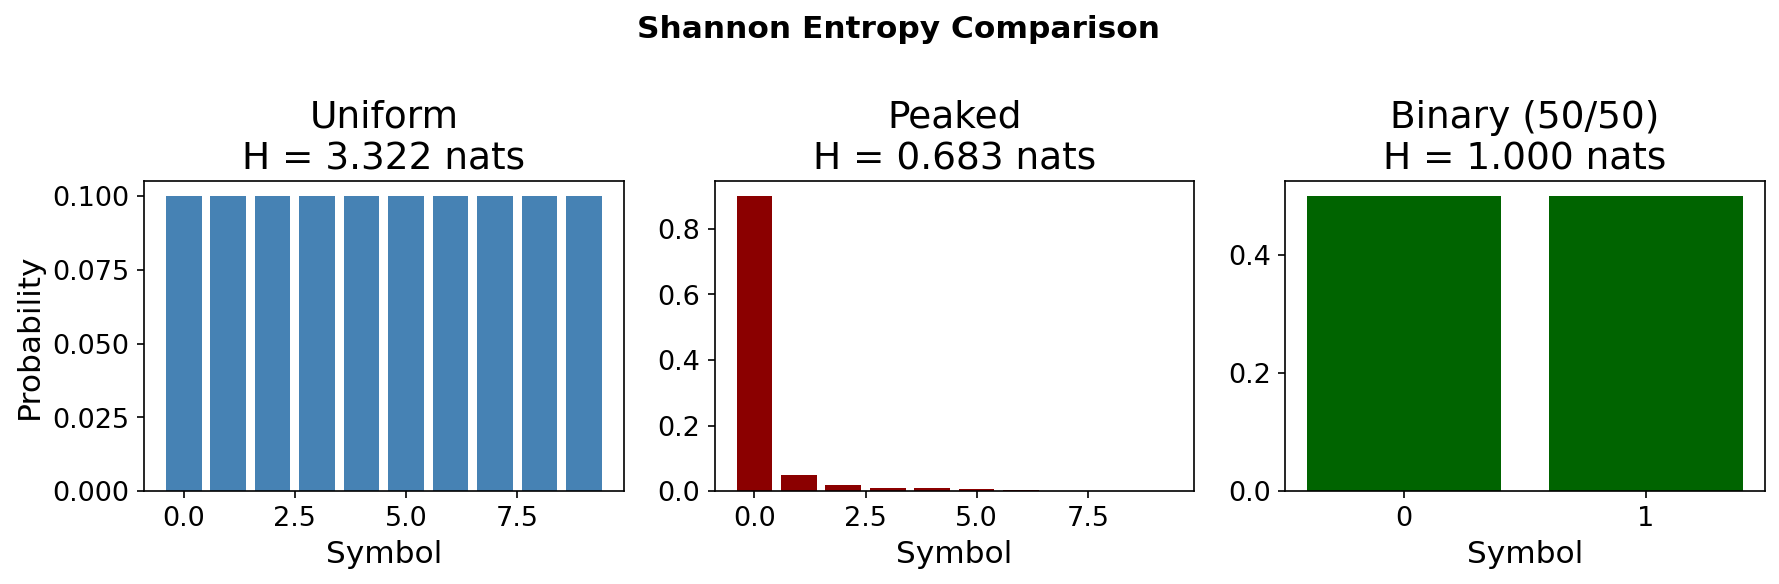

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(range(10), uniform_probs, color="steelblue")
axes[0].set_title(f"Uniform\nH = {h_uniform:.3f} nats")
axes[0].set_xlabel("Symbol")
axes[0].set_ylabel("Probability")

axes[1].bar(range(10), peaked_probs, color="darkred")
axes[1].set_title(f"Peaked\nH = {h_peaked:.3f} nats")
axes[1].set_xlabel("Symbol")

axes[2].bar(range(2), binary_probs, color="darkgreen")
axes[2].set_title(f"Binary (50/50)\nH = {h_binary:.3f} nats")
axes[2].set_xlabel("Symbol")
axes[2].set_xticks([0, 1])

plt.suptitle("Shannon Entropy Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Plugin Entropy

The plugin estimator computes entropy by first estimating symbol frequencies from the
data and then plugging them into the Shannon formula. We compute it for the full series
and for each regime individually to see how entropy varies across market conditions.

In [10]:
quantile_seq = pymlfinance.features.quantile_encode(series, num_bins=8)
h_plugin = pymlfinance.features.plugin_entropy(quantile_seq, num_symbols=8)
print(f"  Full series (8 bins): {h_plugin:.4f}")

# Per-regime
regime_names = []
regime_entropies = []
for name, start, end in [("Trending", 0, 100), ("Random", 100, 250),
                          ("Mean-rev", 250, 350), ("Random2", 350, 500)]:
    seg = pymlfinance.features.quantile_encode(series[start:end], num_bins=8)
    h = pymlfinance.features.plugin_entropy(seg, num_symbols=8)
    print(f"  {name:>10s} [{start}-{end}]: {h:.4f}")
    regime_names.append(name)
    regime_entropies.append(h)

  Full series (8 bins): 3.0000
    Trending [0-100]: 2.9988
      Random [100-250]: 2.9996
    Mean-rev [250-350]: 2.9988
     Random2 [350-500]: 2.9996


## Kontoyiannis Entropy

The Kontoyiannis estimator uses the longest-match-length approach, measuring how far
back in the sequence one must look to find a match for the current substring. Longer
matches imply lower entropy (more structure). The `window` parameter controls the
matching context size.

In [11]:
kont_windows = [10, 20, 50]
kont_values = []
for window in kont_windows:
    h_kont = pymlfinance.features.kontoyiannis_entropy(quantile_seq, window=window)
    print(f"  Window={window}: {h_kont:.4f}")
    kont_values.append(h_kont)

  Window=10: 0.9135
  Window=20: 1.0743
  Window=50: 1.1961


## Lempel-Ziv Complexity

Lempel-Ziv complexity counts the number of distinct substrings encountered when parsing
the sequence left to right. A random binary sequence has maximum LZ complexity, while a
periodic or structured sequence has low complexity. This is the same principle behind
LZ77/LZ78 compression.

In [12]:
lz = pymlfinance.features.lempel_ziv_complexity(binary)
print(f"  Full series: {lz} distinct patterns")
print(f"  Normalized: {lz / len(binary):.4f} patterns/symbol")

# Per-regime
lz_names = []
lz_values = []
lz_normalized = []
for name, start, end in [("Trending", 0, 100), ("Random", 100, 250),
                          ("Mean-rev", 250, 350), ("Random2", 350, 500)]:
    seg_binary = pymlfinance.features.binary_encode(series[start:end])
    lz_seg = pymlfinance.features.lempel_ziv_complexity(seg_binary)
    print(f"  {name:>10s}: {lz_seg} patterns, normalized={lz_seg/len(seg_binary):.4f}")
    lz_names.append(name)
    lz_values.append(lz_seg)
    lz_normalized.append(lz_seg / len(seg_binary))

  Full series: 14 distinct patterns
  Normalized: 0.0280 patterns/symbol
    Trending: 1 patterns, normalized=0.0100
      Random: 9 patterns, normalized=0.0600
    Mean-rev: 4 patterns, normalized=0.0400
     Random2: 6 patterns, normalized=0.0400


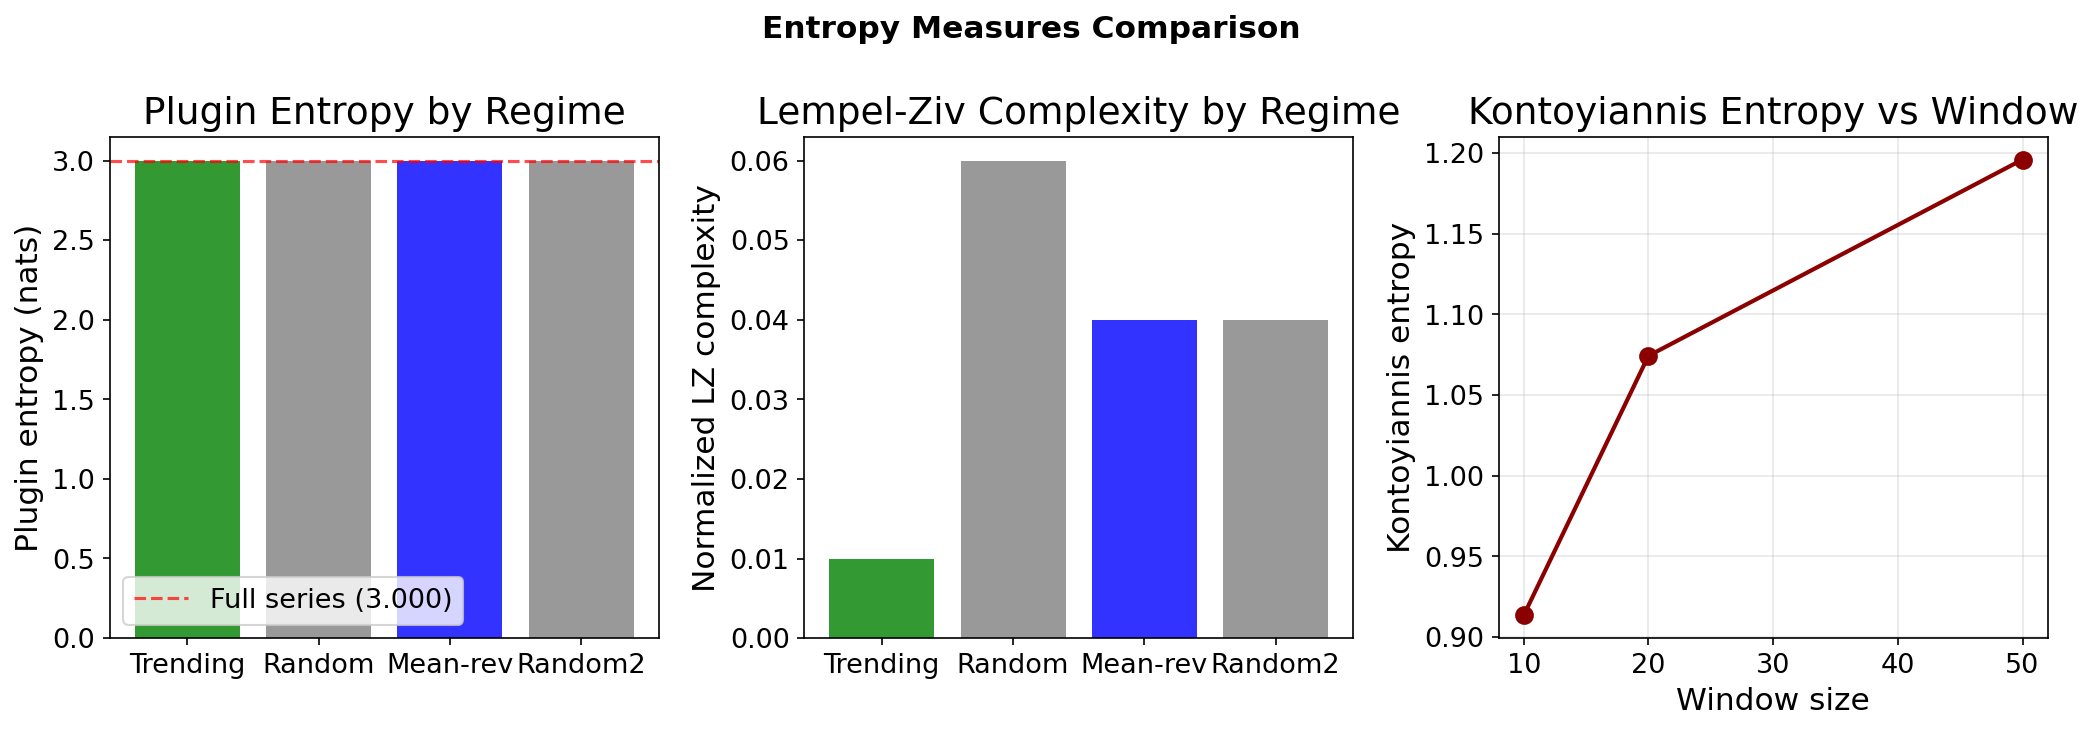

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Plugin entropy by regime
colors = ["green", "gray", "blue", "gray"]
axes[0].bar(regime_names, regime_entropies, color=colors, alpha=0.8)
axes[0].axhline(y=h_plugin, color="red", linestyle="--", alpha=0.7, label=f"Full series ({h_plugin:.3f})")
axes[0].set_ylabel("Plugin entropy (nats)")
axes[0].set_title("Plugin Entropy by Regime")
axes[0].legend()

# LZ complexity by regime (normalized)
axes[1].bar(lz_names, lz_normalized, color=colors, alpha=0.8)
axes[1].set_ylabel("Normalized LZ complexity")
axes[1].set_title("Lempel-Ziv Complexity by Regime")

# Kontoyiannis entropy vs window size
axes[2].plot(kont_windows, kont_values, "o-", color="darkred", linewidth=2, markersize=8)
axes[2].set_xlabel("Window size")
axes[2].set_ylabel("Kontoyiannis entropy")
axes[2].set_title("Kontoyiannis Entropy vs Window")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Entropy Measures Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Polars API

Encoding and entropy functions are available through the Polars `.ml` namespace,
enabling seamless integration into DataFrame-based workflows.

In [14]:
df = pl.DataFrame({"value": series})
result = df.with_columns(
    pl.col("value").ml.binary_encode().alias("binary"),
    pl.col("value").ml.quantile_encode(n_bins=8).alias("quantile"),
    pl.col("value").ml.sigma_encode(n_bands=3).alias("sigma"),
)
print(f"  Encoded DataFrame: {result.shape}")
print(result.head(5))

  Encoded DataFrame: (500, 4)
shape: (5, 4)
┌──────────┬────────┬──────────┬───────┐
│ value    ┆ binary ┆ quantile ┆ sigma │
│ ---      ┆ ---    ┆ ---      ┆ ---   │
│ f64      ┆ i32    ┆ i32      ┆ i32   │
╞══════════╪════════╪══════════╪═══════╡
│ 0.010993 ┆ 1      ┆ 3        ┆ 0     │
│ 0.020717 ┆ 1      ┆ 3        ┆ 0     │
│ 0.032012 ┆ 1      ┆ 4        ┆ 0     │
│ 0.045058 ┆ 1      ┆ 4        ┆ 0     │
│ 0.05459  ┆ 1      ┆ 4        ┆ 0     │
└──────────┴────────┴──────────┴───────┘


In [15]:
# Scalar entropy measures
binary_col = [bool(b) for b in binary]
entropy_df = pl.DataFrame({"binary": binary_col, "quantile": quantile_seq})
lz_pl = entropy_df.select(pl.col("binary").ml.lempel_ziv_complexity()).item()
print(f"  Polars LZ complexity: {lz_pl}")

shannon_probs = pl.DataFrame({"probs": uniform_probs.tolist()})
h_pl = shannon_probs.select(pl.col("probs").ml.shannon_entropy()).item()
print(f"  Polars Shannon entropy: {h_pl:.4f}")

  Polars LZ complexity: 14.0
  Polars Shannon entropy: 3.3219


## Exercises

1. **Periodic series** -- Generate a perfectly periodic series (e.g., repeating `[0, 1, 0, 1, ...]`) and measure its entropy. It should be significantly lower than a random series.

2. **Cross-regime comparison** -- Compare all entropy measures (plugin, Kontoyiannis, LZ) across the four regimes. Which measure best discriminates trending from random behavior?

3. **Regime detection** -- Use rolling entropy features (computed on sliding windows) as inputs to a classifier for detecting market regime changes.